# 📚 **Recommendation Systems: Building a Netflix-Style Model**

This notebook provides a comprehensive guide to understanding recommendation systems, including types, metrics, and methods. It walks you through building a basic Netflix-like recommendation engine using Python, collaborative filtering, and matrix factorization.

* What recommendation systems are
* Types of recommendation systems
* Important metrics used for evaluation
* How to preprocess data
* How to build user-based and item-based recommendation models
* How to implement matrix factorization using SVD
* How to evaluate the system
* Extensions and best practices

---

## 📘 **Part 1 – Introduction to Recommendation Systems**

### What is a Recommendation System?

Recommendation systems suggest items to users based on their preferences and behavior. They are widely used in:

✔ Online streaming platforms like Netflix  
✔ E-commerce sites like Amazon  
✔ Social media platforms like YouTube  
✔ News platforms, travel apps, etc.

### Key Objectives:
- Help users discover content
- Increase engagement
- Improve user satisfaction

### Types of Recommendation Systems

1. **Content-Based Filtering**
   - Recommends items similar to those a user has liked before
   - Uses features like genres, keywords, etc.

2. **Collaborative Filtering**
   - Based on user-item interactions
   - Can be **user-based** or **item-based**

3. **Hybrid Systems**
   - Combines both content and collaborative approaches

### Challenges
✔ Cold start problem  
✔ Sparsity of data  
✔ Scalability  
✔ Diversity vs relevance


---

## 📘 **Part 2 – Dataset**

We will use the **MovieLens** dataset, a standard dataset for recommendation tasks, containing:

✔ User IDs  
✔ Movie IDs  
✔ Ratings  
✔ Timestamps  
✔ Movie titles and genres

In [3]:
!pip uninstall -y numpy scipy scikit-learn gensim
!pip install numpy scipy scikit-learn gensim

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3
  Using cached numpy-2.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.16.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scip

In [1]:
# Downloading the dataset
!wget -q http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip

import pandas as pd

# Load datasets
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

# Show first few rows
ratings.head()



,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [2]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


**Exercise:**

✔ Explore how many unique users and movies are in the dataset.

✔ Check how many ratings each movie has.

---

## 📘 **Part 3 – Exploratory Data Analysis (EDA)**


### Key insights:
✔ Distribution of ratings  
✔ Popular movies  
✔ User behavior patterns

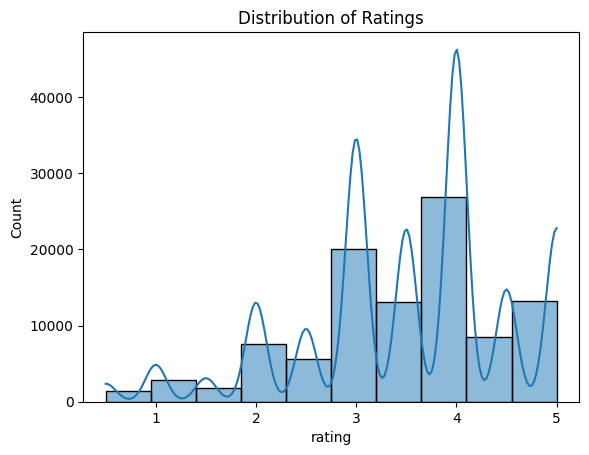

Top Rated Movies:
 movieId
356                           Forrest Gump (1994)
318              Shawshank Redemption, The (1994)
296                           Pulp Fiction (1994)
593              Silence of the Lambs, The (1991)
2571                           Matrix, The (1999)
260     Star Wars: Episode IV - A New Hope (1977)
480                          Jurassic Park (1993)
110                             Braveheart (1995)
589             Terminator 2: Judgment Day (1991)
527                       Schindler's List (1993)
Name: title, dtype: object


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of ratings
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title('Distribution of Ratings')
plt.show()

# Top-rated movies by count
top_movies = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)
top_movies = movies.set_index('movieId').loc[top_movies.index]['title']
print("Top Rated Movies:\n", top_movies)

**Exercise:**

✔ Plot the distribution of the number of ratings per movie.

✔ Find the movies with the highest average rating (consider only movies with at least 50 ratings).

---

## 📘 **Part 4 – Building a User-Based Collaborative Filtering Model**

User-based filtering recommends items based on similar users’ preferences.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Create user-item matrix
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Convert to sparse matrix for efficiency
matrix = csr_matrix(user_movie_matrix.values)

# Compute cosine similarity between users
user_similarity = cosine_similarity(matrix)

In [6]:
user_similarity

array([[1.        , 0.02728287, 0.05972026, ..., 0.29109737, 0.09357193,
        0.14532081],
       [0.02728287, 1.        , 0.        , ..., 0.04621095, 0.0275654 ,
        0.10242675],
       [0.05972026, 0.        , 1.        , ..., 0.02112846, 0.        ,
        0.03211875],
       ...,
       [0.29109737, 0.04621095, 0.02112846, ..., 1.        , 0.12199271,
        0.32205486],
       [0.09357193, 0.0275654 , 0.        , ..., 0.12199271, 1.        ,
        0.05322546],
       [0.14532081, 0.10242675, 0.03211875, ..., 0.32205486, 0.05322546,
        1.        ]])

In [7]:
# Recommend top N movies to a user based on similar users
import numpy as np
import pandas as pd

def recommend_user(user_id, user_similarity, user_movie_matrix, top_n=5):
    user_index = user_id - 1  # assuming userId starts from 1
    sim_scores = user_similarity[user_index]
    similar_users = list(enumerate(sim_scores))
    similar_users = sorted(similar_users, key=lambda x: x[1], reverse=True)[1:]  # exclude self

    recommended = pd.Series(dtype=float)
    for other_user, score in similar_users[:10]:
        other_user_ratings = user_movie_matrix.iloc[other_user]
        recommended = pd.concat([recommended, other_user_ratings[other_user_ratings > 0]])


    recommended = recommended.groupby(recommended.index).mean()
    recommended = recommended.sort_values(ascending=False)

    # Exclude already rated movies
    rated_movies = user_movie_matrix.iloc[user_index][user_movie_matrix.iloc[user_index] > 0].index
    recommended = recommended.drop(rated_movies, errors='ignore')

    top_recommendations = recommended.head(top_n).index
    return movies.set_index('movieId').loc[top_recommendations]['title']

In [8]:
# Example: Recommend movies for user 1
recommend_user(1, user_similarity, user_movie_matrix)

,title
1719,"Sweet Hereafter, The (1997)"
3037,Little Big Man (1970)
3262,Twin Peaks: Fire Walk with Me (1992)
3201,Five Easy Pieces (1970)
6460,"Trial, The (Procès, Le) (1962)"


**Exercise:**
✔ Modify the function to return not only titles but also average rating and similarity score.

---

## 📘 **Part 5 – Building an Item-Based Collaborative Filtering Model**

Item-based filtering recommends items similar to the ones a user has already rated highly.


In [9]:
# Transpose matrix for item-based similarity
item_matrix = user_movie_matrix.T
item_similarity = cosine_similarity(item_matrix)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(item_similarity, index=item_matrix.index, columns=item_matrix.index)

In [10]:
# Recommend similar items to a given movie
def recommend_item(movie_id, item_similarity_df, top_n=5):
    similar_items = item_similarity_df[movie_id].sort_values(ascending=False).drop(movie_id)
    top_items = similar_items.head(top_n).index
    return movies.set_index('movieId').loc[top_items]['title']

# Example: Similar movies to Toy Story
toy_story_id = movies[movies['title'].str.contains('Toy Story')].iloc[0]['movieId']
recommend_item(toy_story_id, item_similarity_df)

,title
movieId,
3114,Toy Story 2 (1999)
480,Jurassic Park (1993)
780,Independence Day (a.k.a. ID4) (1996)
260,Star Wars: Episode IV - A New Hope (1977)
356,Forrest Gump (1994)


**Exercise:**

✔ Find similar movies for at least 5 popular movies.


---

## 📘 **Part 6 – Matrix Factorization using SVD**

Matrix factorization is a popular approach to handle sparse data by projecting users and items into a latent space.

We’ll use `TruncatedSVD` from `scikit-learn` as a simple method to implement this.

In [11]:
from sklearn.decomposition import TruncatedSVD

# Apply SVD
svd = TruncatedSVD(n_components=20)
matrix_reduced = svd.fit_transform(user_movie_matrix)

# Reconstruct approximation
reconstructed_matrix = svd.inverse_transform(matrix_reduced)

In [12]:
# Recommend based on reconstructed matrix
def recommend_svd(user_id, reconstructed_matrix, user_movie_matrix, top_n=5):
    user_index = user_id - 1
    scores = reconstructed_matrix[user_index]
    rated = user_movie_matrix.iloc[user_index]
    unrated_indices = rated[rated == 0].index
    recommendations = pd.Series(scores, index=user_movie_matrix.columns)
    recommendations = recommendations.loc[unrated_indices]
    recommendations = recommendations.sort_values(ascending=False)
    top_recommendations = recommendations.head(top_n).index
    return movies.set_index('movieId').loc[top_recommendations]['title']

recommend_svd(1, reconstructed_matrix, user_movie_matrix)

,title
movieId,
589,Terminator 2: Judgment Day (1991)
1200,Aliens (1986)
2762,"Sixth Sense, The (1999)"
1968,"Breakfast Club, The (1985)"
1036,Die Hard (1988)


**Exercise:**

✔ Experiment with different values of `n_components` and observe the impact.

---

## 📘 **Part 7 – Evaluation Metrics**

✔ **Mean Absolute Error (MAE)**  
✔ **Root Mean Squared Error (RMSE)**  
✔ **Precision and Recall**  
✔ **Coverage**  
✔ **Diversity and Novelty**


In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Example: Compute RMSE
actual = user_movie_matrix.values
predicted = reconstructed_matrix
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("RMSE:", rmse)

RMSE: 0.35208258108415375


**Exercise:**
✔ Split data into train/test sets and compute RMSE on the test set.

---

## 📘 **Part 8 – Extensions and Best Practices**

✔ Address the cold start problem using content-based features  
✔ Apply cross-validation for better evaluation  
✔ Tune hyperparameters  
✔ Experiment with deep learning models like autoencoders and neural collaborative filtering  
✔ Use implicit feedback like clicks and views for recommendations  
✔ Combine multiple approaches to build robust systems

---

## 📘 **Final Assignment**

1. Build a recommendation system using both user-based and item-based collaborative filtering.
2. Implement matrix factorization using SVD and compare the performance.
3. Evaluate your models using RMSE.
4. Experiment with different numbers of latent factors.
5. Optionally, enhance your model with content-based filtering using movie genres.

---

## ✅ Summary

This notebook has covered:

✔ Fundamentals of recommendation systems

✔ Popular algorithms like collaborative filtering and matrix factorization

✔ Evaluation techniques

✔ Practical implementation using Python libraries

✔ Exercises and extensions for deeper learning

---


## 📘 **Content-Based Filtering – In Depth**

### ✅ **What is Content-Based Filtering?**

Content-based filtering recommends items similar to what a user has liked or interacted with before by analyzing the features of items.

It’s based on:

✔ Item properties (genres, categories, text descriptions, etc.)
✔ User preferences based on past interactions
✔ Similarity between items computed using features

**Example**:
If a user has watched a lot of action movies, the system recommends other action-packed films based on genre, cast, or plot keywords.

---

### ✅ **Steps in Content-Based Filtering**

1. **Collect Item Features**
   Movie genres, descriptions, actors, etc.

2. **Create Feature Vectors**
   Transform textual or categorical data into numerical vectors.

3. **Profile User Preferences**
   Aggregate features from items the user has interacted with.

4. **Calculate Similarity**
   Find items similar to user preferences or items they've liked.

5. **Make Recommendations**
   Recommend items based on similarity scores.

---

### ✅ **How It Works – Example Workflow**

1. Movie `A` → Genres: Action, Adventure → Features: \[1,1,0,...]
2. Movie `B` → Genres: Action, Sci-Fi → Features: \[1,0,1,...]
3. Compute similarity between `A` and `B` → Recommend if similar

---

## 📘 **Practical Implementation – Using MovieLens Dataset**

We'll focus on using movie genres as features.

---

### ✅ **Step 1 – Preprocessing Features**

```python
# Import necessary libraries
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Load datasets
movies = pd.read_csv('ml-latest-small/movies.csv')

# Split genres into individual columns
movies['genres'] = movies['genres'].str.split('|')
all_genres = set(g for genres in movies['genres'] for g in genres)

# Create one-hot encoding for genres
for genre in all_genres:
    movies[genre] = movies['genres'].apply(lambda x: int(genre in x))

movies.head()
```

✔ Each genre becomes a column with binary encoding (1 if the movie has that genre, 0 otherwise).

---

### ✅ **Step 2 – Create a Feature Matrix**

```python
# Select only genre columns
genre_features = list(all_genres)
movie_features = movies.set_index('movieId')[genre_features]

movie_features.head()
```

---

### ✅ **Step 3 – Compute Similarity Between Movies**

```python
# Compute cosine similarity between movies based on genres
similarity_matrix = cosine_similarity(movie_features)

# Convert to DataFrame for easier handling
similarity_df = pd.DataFrame(similarity_matrix, index=movie_features.index, columns=movie_features.index)
```

---

### ✅ **Step 4 – Recommend Similar Movies**

```python
def recommend_content_based(movie_id, similarity_df, top_n=5):
    # Get similarity scores for the movie
    scores = similarity_df[movie_id]
    scores = scores.sort_values(ascending=False)
    # Exclude the same movie
    scores = scores.drop(movie_id, errors='ignore')
    # Get top similar movies
    top_movies = scores.head(top_n).index
    return movies.set_index('movieId').loc[top_movies]['title']

# Example: Recommend movies similar to "Toy Story (1995)"
toy_story_id = movies[movies['title'].str.contains('Toy Story')].iloc[0]['movieId']
recommend_content_based(toy_story_id, similarity_df)
```

---

### ✅ **Step 5 – User Profile Based Recommendations**

Now, instead of recommending similar movies to one movie, we can recommend movies based on the user's past preferences.

#### Create User Profile

```python
# Load ratings
ratings = pd.read_csv('ml-latest-small/ratings.csv')

# Example: Build user profile for user_id = 1
user_id = 1
user_ratings = ratings[ratings['userId'] == user_id]
user_movies = user_ratings.merge(movies, on='movieId')

# Weighted sum of genres based on ratings
user_profile = movie_features.loc[user_movies['movieId']].T.dot(user_movies['rating'])

# Normalize user profile
user_profile = user_profile / user_profile.sum()

user_profile
```

---

#### Recommend Based on User Profile

```python
def recommend_for_user(user_profile, movie_features, rated_movies, top_n=5):
    # Compute similarity between user profile and all movies
    scores = cosine_similarity([user_profile], movie_features)[0]
    scores_series = pd.Series(scores, index=movie_features.index)
    # Exclude already rated movies
    scores_series = scores_series.drop(rated_movies, errors='ignore')
    top_movies = scores_series.sort_values(ascending=False).head(top_n).index
    return movies.set_index('movieId').loc[top_movies]['title']

rated_movies = user_movies['movieId']
recommend_for_user(user_profile, movie_features, rated_movies)
```

---

## ✅ Exercises for Students

1. ✔ Preprocess genres for all movies.
2. ✔ Compute similarity between movies using cosine similarity.
3. ✔ Implement a function to recommend similar movies given one movie.
4. ✔ Build a user profile by aggregating ratings.
5. ✔ Recommend movies based on user preferences using cosine similarity.
6. ❓ Extend the feature set by including movie descriptions using TF-IDF.
7. ❓ Compare content-based recommendations with collaborative filtering results.

---

## ✅ Key Takeaways

✔ Content-based filtering is intuitive and relies on item features
✔ It helps especially when collaborative filtering is limited by data sparsity
✔ Cosine similarity is widely used to measure similarity between feature vectors
✔ User profiles can be built by aggregating past interactions
✔ Hybrid systems combining content and collaborative filtering give better results

---


## 📘 **Collaborative Filtering – In Depth**

### ✅ **What is Collaborative Filtering?**

Collaborative Filtering (CF) recommends items based on the preferences of similar users or similar items. It leverages past user interactions like ratings, clicks, or purchases to find patterns and predict what a user might like.

---

### ✅ **Types of Collaborative Filtering**

1. **User-Based Collaborative Filtering**

   * Finds users similar to the target user
   * Recommends items liked by similar users
   * Example: “People like you also liked these movies”

2. **Item-Based Collaborative Filtering**

   * Finds items similar to what the user has liked
   * Recommends similar items based on interaction patterns
   * Example: “Users who watched this also watched…”

3. **Model-Based Collaborative Filtering**

   * Uses machine learning or matrix factorization techniques
   * Includes algorithms like SVD, ALS, and neural networks

---

### ✅ **Key Concepts**

✔ **Sparsity** – Many users don't rate many items, making the matrix sparse
✔ **Cold Start** – Lack of data for new users/items
✔ **Scalability** – Efficient algorithms are needed for large datasets
✔ **Similarity Measures** – Cosine similarity, Pearson correlation, etc.

---

## 📘 **Implementation – User-Based Collaborative Filtering**

### ✅ **Step 1 – Create User-Item Interaction Matrix**

```python
import pandas as pd
from scipy.sparse import csr_matrix

# Load the dataset
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

# Create user-item matrix
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Convert to sparse matrix for efficiency
sparse_matrix = csr_matrix(user_item_matrix.values)

user_item_matrix.head()
```

---

### ✅ **Step 2 – Compute User Similarity**

```python
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between users
user_similarity = cosine_similarity(sparse_matrix)

# Convert into DataFrame for better understanding
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

user_similarity_df.head()
```

---

### ✅ **Step 3 – Finding Similar Users**

```python
def find_similar_users(user_id, user_similarity_df, top_n=5):
    sim_scores = user_similarity_df.loc[user_id]
    sim_scores = sim_scores.sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_id, errors='ignore')  # Exclude self
    return sim_scores.head(top_n)

# Example: Find users similar to user 1
find_similar_users(1, user_similarity_df)
```

---

### ✅ **Step 4 – Generate Recommendations**

```python
def recommend_user_based(user_id, user_similarity_df, user_item_matrix, top_n=5):
    similar_users = find_similar_users(user_id, user_similarity_df, top_n=10)
    similar_users = similar_users.index
    
    # Aggregate ratings from similar users
    similar_users_ratings = user_item_matrix.loc[similar_users]
    mean_ratings = similar_users_ratings.mean(axis=0)
    
    # Exclude movies already rated by the target user
    user_rated_movies = user_item_matrix.loc[user_id]
    unrated_movies = user_rated_movies[user_rated_movies == 0].index
    recommendations = mean_ratings.loc[unrated_movies]
    
    # Get top N recommendations
    top_recommendations = recommendations.sort_values(ascending=False).head(top_n)
    return movies.set_index('movieId').loc[top_recommendations.index]['title']

# Example: Recommend movies for user 1
recommend_user_based(1, user_similarity_df, user_item_matrix)
```

---

## 📘 **Implementation – Item-Based Collaborative Filtering**

### ✅ **Step 1 – Create Item Similarity Matrix**

```python
# Transpose user-item matrix to item-user matrix
item_user_matrix = user_item_matrix.T

# Compute similarity between items
item_similarity = cosine_similarity(item_user_matrix)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_matrix.index, columns=item_user_matrix.index)
```

---

### ✅ **Step 2 – Find Similar Items**

```python
def find_similar_items(movie_id, item_similarity_df, top_n=5):
    sim_scores = item_similarity_df.loc[movie_id]
    sim_scores = sim_scores.sort_values(ascending=False)
    sim_scores = sim_scores.drop(movie_id, errors='ignore')  # Exclude self
    return sim_scores.head(top_n)

# Example: Find similar items to a movie
movie_id = movies[movies['title'].str.contains('Toy Story')].iloc[0]['movieId']
find_similar_items(movie_id, item_similarity_df)
```

---

### ✅ **Step 3 – Generate Recommendations Based on Items**

```python
def recommend_item_based(movie_id, item_similarity_df, user_item_matrix, user_id, top_n=5):
    # Get similar items
    similar_items = find_similar_items(movie_id, item_similarity_df, top_n=20)
    
    # Get movies user has already rated
    user_ratings = user_item_matrix.loc[user_id]
    user_rated = user_ratings[user_ratings > 0].index
    
    # Filter out already rated movies
    recommendations = similar_items.drop(user_rated, errors='ignore')
    
    # Get top N recommendations
    top_recommendations = recommendations.head(top_n).index
    return movies.set_index('movieId').loc[top_recommendations]['title']

# Example: Recommend similar movies to "Toy Story" for user 1
recommend_item_based(movie_id, item_similarity_df, user_item_matrix, 1)
```

---

## 📘 **Model-Based Collaborative Filtering – Matrix Factorization**

Beyond the nearest neighbors approach, matrix factorization decomposes the user-item matrix into latent features.

---

### ✅ **Step 1 – Using Truncated SVD**

```python
from sklearn.decomposition import TruncatedSVD

# Apply SVD
svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_

# Reconstruct the matrix
reconstructed_matrix = user_factors.dot(item_factors)
```

---

### ✅ **Step 2 – Generate Recommendations**

```python
import numpy as np

def recommend_svd(user_id, reconstructed_matrix, user_item_matrix, top_n=5):
    user_index = user_id - 1
    user_ratings = reconstructed_matrix[user_index]
    already_rated = user_item_matrix.iloc[user_index] > 0
    user_ratings[already_rated] = 0  # Avoid recommending already rated items
    
    top_indices = np.argsort(user_ratings)[::-1][:top_n]
    top_movie_ids = user_item_matrix.columns[top_indices]
    return movies.set_index('movieId').loc[top_movie_ids]['title']

# Example: Recommend for user 1
recommend_svd(1, reconstructed_matrix, user_item_matrix)
```

---

## ✅ Evaluation – Measuring Collaborative Filtering Performance

✔ **Root Mean Squared Error (RMSE)**
✔ **Mean Absolute Error (MAE)**
✔ **Precision and Recall** for top-N recommendations
✔ **Coverage** – How many items can be recommended
✔ **Diversity** – Are recommendations varied and useful?

---

### Example – Compute RMSE

```python
from sklearn.metrics import mean_squared_error

actual = user_item_matrix.values
predicted = reconstructed_matrix
rmse = mean_squared_error(actual, predicted, squared=False)
print("RMSE:", rmse)
```

---

## ✅ Exercises for Students

1. ✔ Build user-based recommendations using cosine similarity.
2. ✔ Build item-based recommendations using cosine similarity.
3. ✔ Implement recommendations using SVD and matrix factorization.
4. ✔ Compare predictions using RMSE.
5. ✔ Try other similarity metrics like Pearson correlation.
6. ✔ Explore adding implicit feedback like clicks or watch duration.
7. ❓ Implement cross-validation and tune parameters like `n_components`.

---

## ✅ Summary

* Collaborative Filtering is powerful for scenarios with rich interaction data.
* User-based CF finds similar users; item-based CF finds similar items.
* Matrix factorization techniques like SVD compress the interaction matrix into meaningful latent factors.
* Evaluating CF models using metrics like RMSE is crucial to ensure recommendation quality.
* Hybrid approaches combining content and collaborative methods often yield the best results.

---

